- **예제 데이터셋: MNIST 손글씨 숫자 데이터**
    - 0부터 9까지의 손글씨 이미지로 구성된 데이터셋이다.
    - 각 이미지는 28x28 픽셀의 그레이스케일 이미지이다.

In [ ]:
# 데이터 로드 및 전처리
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical  # 원-핫 인코딩 함수

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(60000, 784).astype('float32') / 255  # (28*28)-> 784로 평탄화 + 0~1 정규화
x_test = x_test.reshape(10000, 784).astype('float32') / 255

y_train = to_categorical(y_train, 10)  # 레이블(0~9)을 10차원 원-핫 벡터로 변환
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Sequential API를 사용한 모델 정의
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))  # 입력(784) -> 은닉(512)
model.add(Dense(256, activation='relu'))  # 은닉(512) -> 은닉(256)
model.add(Dense(10, activation='softmax'))  # 은닉(256) -> 출력(10)

c:\Users\Playdata\multimodal\multi_venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

- **손실 함수와 옵티마이저 설정**
    - **손실 함수**: `categorical_crossentropy` (다중 클래스 분류에 사용)
    - **옵티마이저**: `adam` (Adaptive Moment Estimation)

In [ ]:
model.compile(
    optimizer='adam',  # adam 옵티마이저로 가중치 업데이트
    loss='categorical_crossentropy',  # 원-핫 라벨용 다중분류 손실함수
    metrics=['accuracy']  # 학습/평가 시 사용할 지표
)

### 모델 학습

- **에포크(Epoch)**: 전체 데이터셋을 학습하는 횟수
- **배치 크기**: 한 번의 업데이트에 사용되는 샘플 수
- **검증 분할**: 전체 데이터의 20%를 검증용으로 사용

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,       # 128개씩 미니배치 학습
    validation_split=0.2  # 검증은 20%
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9265 - loss: 0.2522 - val_accuracy: 0.9663 - val_loss: 0.1155
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9721 - loss: 0.0918 - val_accuracy: 0.9693 - val_loss: 0.1012
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9833 - loss: 0.0548 - val_accuracy: 0.9751 - val_loss: 0.0844
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9867 - loss: 0.0414 - val_accuracy: 0.9758 - val_loss: 0.0871
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9911 - loss: 0.0284 - val_accuracy: 0.9798 - val_loss: 0.0728
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9766 - val_loss: 0.0913
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9943 - loss: 0.0161 - val_accuracy: 0.9768 - val_loss: 0.0948
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9942 - loss: 0.0170 - val_accura

In [6]:
# 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test)
print('테스트 손실 값:', test_loss)
print('테스트 정확도:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.0918
테스트 손실 값: 0.09178155660629272
테스트 정확도: 0.9767000079154968


In [ ]:
# 테스트 데이터의 첫 번째 이미지 예측
import numpy as np

predictions = model.predict(x_test)  # 테스트셋 전체에 대한 클래스 확률 예측
predicted_label = np.argmax(predictions[0])  # 0번째 샘플의 가장 큰 확률의 인덱스
true_label = np.argmax(y_test[0])  # 0번째 샘플의 원-핫 정답에서 클래스 인덱스 추출

print('예측된 레이블:', predicted_label)
print('실제 레이블:', true_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
예측된 레이블: 7
실제 레이블: 7


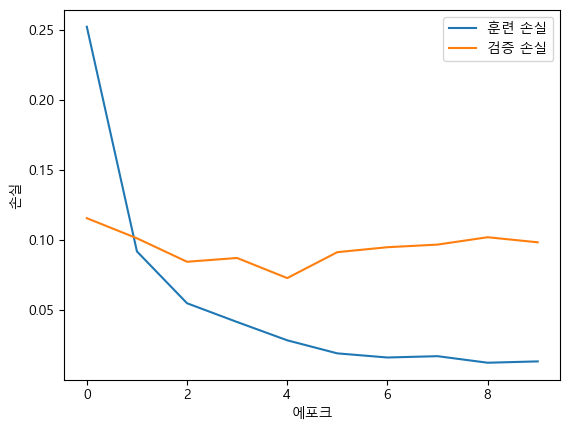

In [8]:
# 훈련 손실과 검증 손실 그래프
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

plt.plot(history.history['loss'], label='훈련 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.xlabel('에포크')
plt.ylabel('손실')
plt.legend()
plt.show()

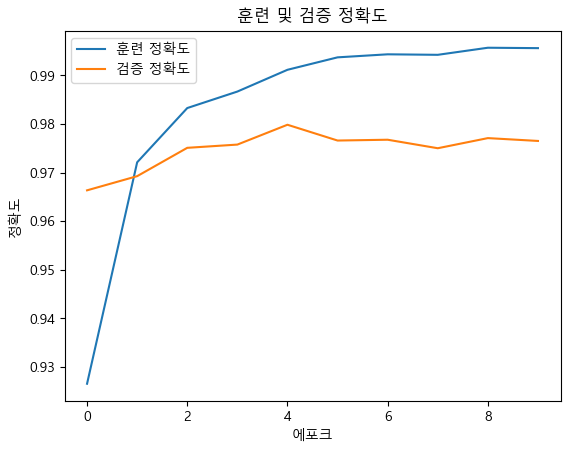

In [9]:
# 훈련 정확도와 검증 정확도 그래프
plt.plot(history.history['accuracy'], label='훈련 정확도')
plt.plot(history.history['val_accuracy'], label='검증 정확도')
plt.title('훈련 및 검증 정확도')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.legend()
plt.show()

In [10]:
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))  # 학습 시 20% 뉴런을 랜덤으로 드롭 (과적합 완화)
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

c:\Users\Playdata\multimodal\multi_venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.01, momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=2)  # val_loss가 2epoch 연속 개선없으면 얼리스탑

history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping]  # 조기종료 콜백 적용
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8336 - loss: 0.5572 - val_accuracy: 0.9325 - val_loss: 0.2361
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9270 - loss: 0.2497 - val_accuracy: 0.9509 - val_loss: 0.1711
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9438 - loss: 0.1889 - val_accuracy: 0.9617 - val_loss: 0.1390
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9552 - loss: 0.1534 - val_accuracy: 0.9643 - val_loss: 0.1228
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9617 - loss: 0.1302 - val_accuracy: 0.9683 - val_loss: 0.1093
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9661 - loss: 0.1135 - val_accuracy: 0.9693 - val_loss: 0.1018
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9703 - loss: 0.0999 - val_accuracy: 0.9697 - val_loss: 0.0965
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9739 - loss: 0.0880 - val_accuracy: 0

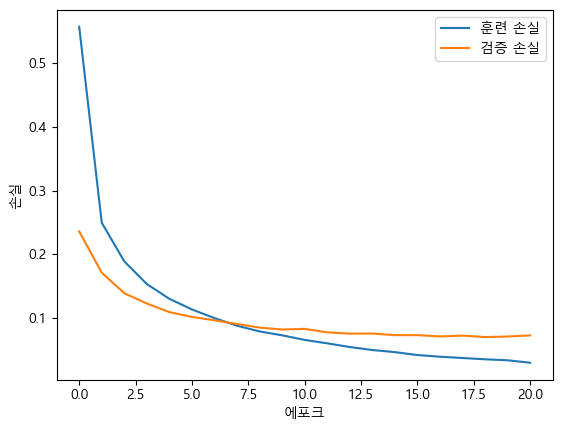

In [13]:
# 훈련 손실과 검증 손실 그래프
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

plt.plot(history.history['loss'], label='훈련 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.xlabel('에포크')
plt.ylabel('손실')
plt.legend()
plt.show()